In [ ]:
from google.colab import drive
import os

if not os.path.ismount('/content/drive'):
    # Clear any existing content at the mount point (use with caution!)
    !rm -rf /content/drive
    drive.mount('/content/drive')
else:
    print("✅ Google Drive is already mounted!")

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (456, 456)  # EfficientNetB5 native input size
BATCH_SIZE = 8         # Reduce for memory reasons (B5 is large)
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Generators ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load EfficientNetB5 Base Model ---
base_model = EfficientNetB5(weights='imagenet', include_top=False, input_shape=(456, 456, 3))
base_model.trainable = False  # freeze base initially

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(len(CLASS_NAMES), activation='softmax')
])

# --- Compile (Phase 1) ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, verbose=1)

# --- Phase 1: Train Top Layers ---
print("\n🔧 Training top layers...\n")
history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Phase 2: Fine-tune Entire Model ---
print("\n🧠 Fine-tuning full model...\n")
base_model.trainable = True
for layer in base_model.layers[:-10]:  # unfreeze most of the layers
    layer.trainable = True

model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9, nesterov=True),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# --- Cosine Annealing Learning Rate ---
def cosine_annealing(epoch):
    max_lr = 1e-3
    min_lr = 1e-5
    return min_lr + (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / EPOCHS_TOTAL)) / 2

lr_scheduler = LearningRateScheduler(cosine_annealing)

# --- Train Phase 2 ---
history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=1
)

# --- Save Model ---
model.save("efficientnetB5_brain_tumor.keras")

Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🔧 Training top layers...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4719 - loss: 3.6223

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


462/462 ━━━━━━━━━━━━━━━━━━━━ 1801s 4s/step - accuracy: 0.4722 - loss: 3.6218 - val_accuracy: 0.8422 - val_loss: 2.7117 - learning_rate: 1.0000e-04
Epoch 2/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 252s 546ms/step - accuracy: 0.6848 - loss: 3.0739 - val_accuracy: 0.8573 - val_loss: 2.6427 - learning_rate: 1.0000e-04
Epoch 3/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 257s 535ms/step - accuracy: 0.7086 - loss: 2.9311 - val_accuracy: 0.8763 - val_loss: 2.6080 - learning_rate: 1.0000e-04
Epoch 4/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 248s 536ms/step - accuracy: 0.7545 - loss: 2.7952 - val_accuracy: 0.8838 - val_loss: 2.5538 - learning_rate: 1.0000e-04
Epoch 5/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 247s 534ms/step - accuracy: 0.7830 - loss: 2.7100 - val_accuracy: 0.8750 - val_loss: 2.5560 - learning_rate: 1.0000e-04
Epoch 6/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 245s 531ms/step - accuracy: 0.7715 - loss: 2.6601 - val_accuracy: 0.8889 - val_loss: 2.5130 - learning_rate: 1.0000e-04
Epoch 7/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 243s 526ms/st

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


99/99 ━━━━━━━━━━━━━━━━━━━━ 349s 3s/step


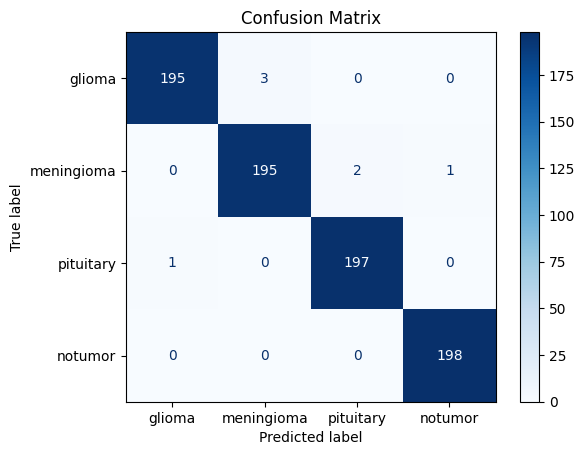

              precision    recall  f1-score   support

      glioma       0.99      0.98      0.99       198
  meningioma       0.98      0.98      0.98       198
   pituitary       0.99      0.99      0.99       198
     notumor       0.99      1.00      1.00       198

    accuracy                           0.99       792
   macro avg       0.99      0.99      0.99       792
weighted avg       0.99      0.99      0.99       792



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predict on test set
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


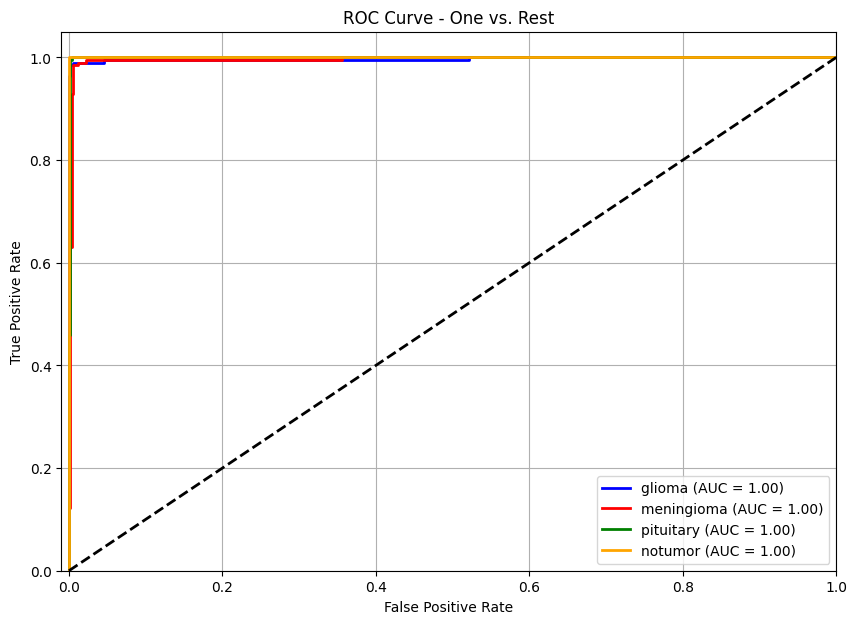

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels
y_true_bin = label_binarize(y_true, classes=np.arange(len(CLASS_NAMES)))
n_classes = y_true_bin.shape[1]

# Compute ROC curve and ROC area
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
colors = cycle(['blue', 'red', 'green', 'orange'])
plt.figure(figsize=(10, 7))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - One vs. Rest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


<ipython-input-8-3589401529>:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


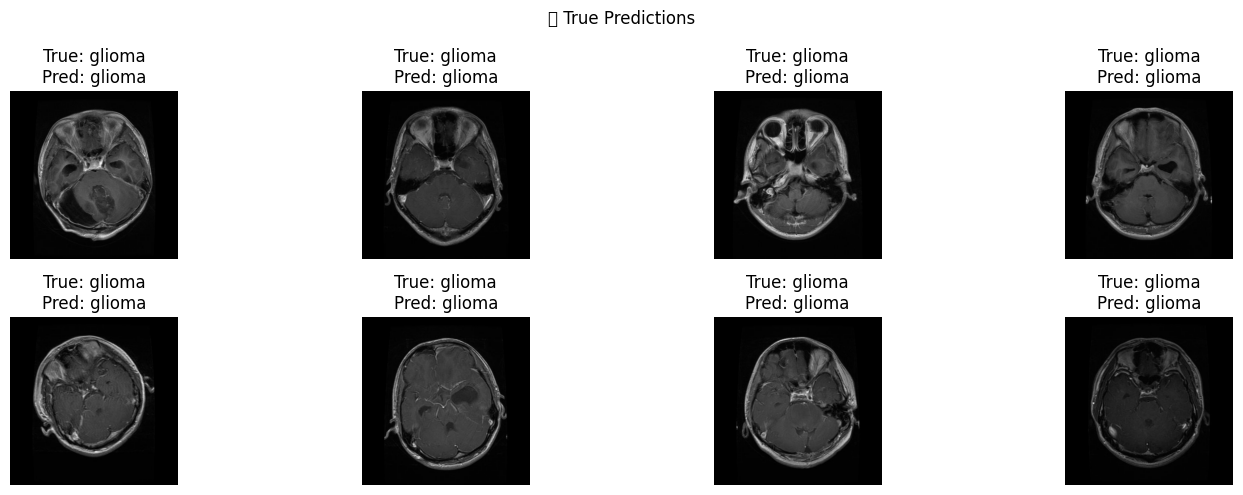

<ipython-input-8-3589401529>:21: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


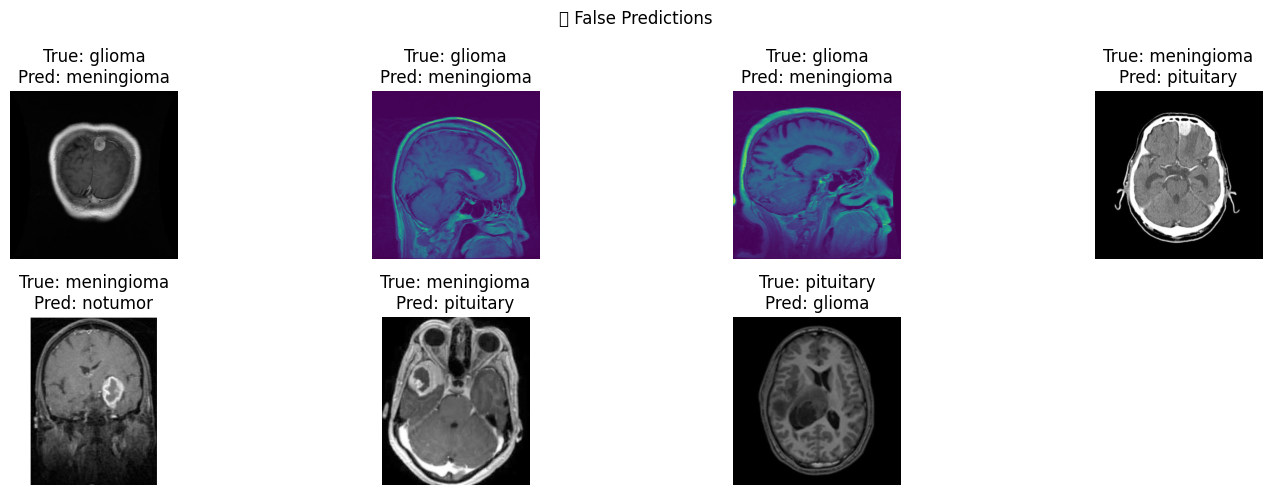

In [ ]:
import matplotlib.pyplot as plt

# Get file paths
filenames = test_generator.filepaths
true_labels = y_true
pred_labels = y_pred

# Get indices of TP and FP
true_indices = np.where(pred_labels == true_labels)[0]
false_indices = np.where(pred_labels != true_labels)[0]

def show_images(indices, title, max_images=8):
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices[:max_images]):
        img = plt.imread(filenames[idx])
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(f"True: {CLASS_NAMES[true_labels[idx]]}\nPred: {CLASS_NAMES[pred_labels[idx]]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Show true and false predictions
show_images(true_indices, "✅ True Predictions")
show_images(false_indices, "❌ False Predictions")


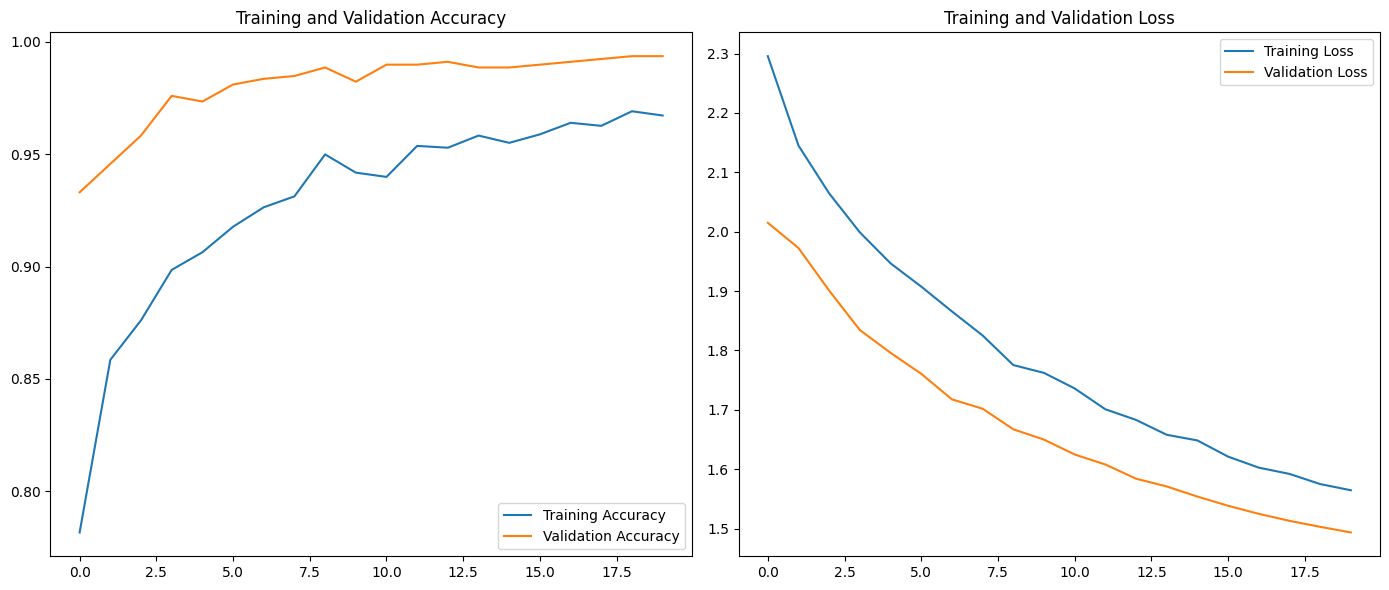

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 6))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.tight_layout()
    plt.show()

plot_training_history(history)


In [ ]:
# --- Evaluate on Test Set ---
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n📊 Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"🧪 Test Loss: {test_loss:.4f}")


99/99 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.9865 - loss: 1.5233

📊 Test Accuracy: 99.12%
🧪 Test Loss: 1.5081


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (456, 456)  # EfficientNetB5 native input size
BATCH_SIZE = 8         # Reduce for memory reasons (B5 is large)
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Generators ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load EfficientNetB5 Base Model ---
base_model = EfficientNetB5(weights='imagenet', include_top=False, input_shape=(456, 456, 3))
base_model.trainable = False  # freeze base initially

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(len(CLASS_NAMES), activation='softmax')
])
model.summary()

Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb5 (Functional)     │ (None, 15, 15, 2048)   │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,146,747 (118.82 MB)

 Trainable params: 2,629,124 (10.03 MB)

 Non-trainable params: 28,517,623 (108.79 MB)